# Proyecto Integrador - Ecommify

## Presentación del proyecto integrador y exploración inicial del dataset Olist

Este notebook hace parte de la Etapa 1: Hoja de ruta del proyecto integrador de la asignatura Diseño y Optimización de Bases de Datos.

El objetivo inicial es cargar y explorar el dataset Brazilian E-commerce / Olist, que será usado como base para diseñar una arquitectura híbrida PostgreSQL-MongoDB para una plataforma e-commerce multivendedor llamada Ecommify.

El análisis exploratorio inicial permitirá revisar:

- Estructura de los archivos CSV.
- Volumen de registros por tabla.
- Tipos de datos.
- Valores nulos.
- Relaciones entre tablas.
- Primeras características temporales, geográficas y transaccionales.


## 1. Contexto del proyecto

Ecommify es una plataforma de comercio electrónico multivendedor especializada en productos tecnológicos.
El sistema debe manejar datos transaccionales, como pedidos, pagos e inventario, y datos analíticos, como catálogo, reseñas y comportamiento de usuarios.

Para el desarrollo del proyecto se utilizará el dataset Brazilian E-commerce / Olist, compuesto por 9 archivos CSV relacionados con clientes, vendedores, productos, pedidos, pagos, reseñas, geolocalización, ítems de pedido y traducción de categorías.


---



## 2. Carga de librerías y conexión con Google Drive

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive




---


Validar la ruta del proyecto

In [ ]:
from pathlib import Path

project_path = Path('/content/drive/MyDrive/Maestria Arquitectura de software/Bases de Datos/Ecommify/data/raw')
raw_data_path = project_path

print("Ruta del proyecto:", project_path)
print("Ruta de datos raw:", raw_data_path)
print("¿Existe la carpeta del proyecto?", project_path.exists())
print("¿Existe la carpeta raw?", raw_data_path.exists())

Ruta del proyecto: /content/drive/MyDrive/Maestria Arquitectura de software/Bases de Datos/Ecommify/data/raw
Ruta de datos raw: /content/drive/MyDrive/Maestria Arquitectura de software/Bases de Datos/Ecommify/data/raw
¿Existe la carpeta del proyecto? True
¿Existe la carpeta raw? True




---


Listar los archivos CSV

In [ ]:
csv_files = sorted(raw_data_path.glob('*.csv'))

print(f"Cantidad de archivos CSV encontrados: {len(csv_files)}")

for file in csv_files:
    print(file.name)

Cantidad de archivos CSV encontrados: 9
olist_customers_dataset.csv
olist_geolocation_dataset.csv
olist_order_items_dataset.csv
olist_order_payments_dataset.csv
olist_order_reviews_dataset.csv
olist_orders_dataset.csv
olist_products_dataset.csv
olist_sellers_dataset.csv
product_category_name_translation.csv




---


Validación de archivos que se espera esten cargados

In [ ]:
expected_files = {
    'olist_customers_dataset.csv',
    'olist_geolocation_dataset.csv',
    'olist_order_items_dataset.csv',
    'olist_order_payments_dataset.csv',
    'olist_order_reviews_dataset.csv',
    'olist_orders_dataset.csv',
    'olist_products_dataset.csv',
    'olist_sellers_dataset.csv',
    'product_category_name_translation.csv'
}

found_files = {file.name for file in csv_files}

missing_files = expected_files - found_files
extra_files = found_files - expected_files

print("Archivos esperados:", len(expected_files))
print("Archivos encontrados:", len(found_files))

if not missing_files and not extra_files:
    print("Validación exitosa: están los 9 archivos esperados.")
else:
    print("Faltan archivos:", missing_files)
    print("Archivos adicionales:", extra_files)

Archivos esperados: 9
Archivos encontrados: 9
Validación exitosa: están los 9 archivos esperados.


## 3. Conexión con Google Drive

Se conectó el notebook de Google Colab con Google Drive para acceder a los archivos originales del dataset Brazilian E-commerce / Olist.

Los archivos CSV se encuentran almacenados en la ruta:

`/content/drive/MyDrive/Maestria Arquitectura de software/Bases de Datos/Ecommify/data/raw`

Se validó la existencia de los 9 archivos requeridos para iniciar el análisis exploratorio de datos.

## 4. Carga de archivos CSV con Pandas

En esta sección se cargan los 9 archivos CSV del dataset Brazilian E-commerce / Olist como DataFrames de Pandas.

In [ ]:
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
pd.set_option('display.width', 120)



---


Cargue de archivos:

In [ ]:
csv_paths = {
    "customers": raw_data_path / "olist_customers_dataset.csv",
    "geolocation": raw_data_path / "olist_geolocation_dataset.csv",
    "order_items": raw_data_path / "olist_order_items_dataset.csv",
    "order_payments": raw_data_path / "olist_order_payments_dataset.csv",
    "order_reviews": raw_data_path / "olist_order_reviews_dataset.csv",
    "orders": raw_data_path / "olist_orders_dataset.csv",
    "products": raw_data_path / "olist_products_dataset.csv",
    "sellers": raw_data_path / "olist_sellers_dataset.csv",
    "category_translation": raw_data_path / "product_category_name_translation.csv"
}

dfs = {}

for name, path in csv_paths.items():
    dfs[name] = pd.read_csv(path)
    print(f"{name}: cargado correctamente con {dfs[name].shape[0]} filas y {dfs[name].shape[1]} columnas")

customers: cargado correctamente con 99441 filas y 5 columnas
geolocation: cargado correctamente con 1000163 filas y 5 columnas
order_items: cargado correctamente con 112650 filas y 7 columnas
order_payments: cargado correctamente con 103886 filas y 5 columnas
order_reviews: cargado correctamente con 99224 filas y 7 columnas
orders: cargado correctamente con 99441 filas y 8 columnas
products: cargado correctamente con 32951 filas y 9 columnas
sellers: cargado correctamente con 3095 filas y 4 columnas
category_translation: cargado correctamente con 71 filas y 2 columnas




---


Creación de variables individuales

In [ ]:
customers = dfs["customers"]
geolocation = dfs["geolocation"]
order_items = dfs["order_items"]
order_payments = dfs["order_payments"]
order_reviews = dfs["order_reviews"]
orders = dfs["orders"]
products = dfs["products"]
sellers = dfs["sellers"]
category_translation = dfs["category_translation"]



---


Validar dimensiones de cada tabla.

La idea es visualizar una tabla resumen con el volumen de registros por archivo.

El codigo python va a mostrar una tabla resumen con el volumen de registros por archivo.

para ello se agrega la siguiente celda:

In [ ]:
summary_tables = []

for name, df in dfs.items():
    summary_tables.append({
        "tabla": name,
        "filas": df.shape[0],
        "columnas": df.shape[1]
    })

summary_df = pd.DataFrame(summary_tables).sort_values(by="filas", ascending=False)
summary_df

,tabla,filas,columnas
1,geolocation,1000163,5
2,order_items,112650,7
3,order_payments,103886,5
0,customers,99441,5
5,orders,99441,8
4,order_reviews,99224,7
6,products,32951,9
7,sellers,3095,4
8,category_translation,71,2




---


Visualizar las primeras filas de cada tabla

In [ ]:
for name, df in dfs.items():
    print("=" * 80)
    print(f"TABLA: {name}")
    print("=" * 80)
    display(df.head())

TABLA: customers


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


TABLA: geolocation


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


TABLA: order_items


...

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


TABLA: sellers


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


TABLA: category_translation


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor




---


Confirmación que todo quedó cargado

In [ ]:
all_loaded = all(isinstance(df, pd.DataFrame) for df in dfs.values())

print("Cantidad de DataFrames cargados:", len(dfs))
print("¿Todos los archivos fueron cargados como DataFrames?", all_loaded)

Cantidad de DataFrames cargados: 9
¿Todos los archivos fueron cargados como DataFrames? True




---
### Resultado de la carga de datos

Se cargaron correctamente los 9 archivos CSV del dataset Brazilian E-commerce / Olist usando Pandas.
Cada archivo fue almacenado como un DataFrame independiente, lo que permitirá realizar el análisis exploratorio inicial, revisar estructura, volumen, tipos de datos, valores nulos y relaciones entre tablas.


---



## 5. Análisis exploratorio inicial del dataset

En esta sección se realiza un EDA fundamental del dataset Brazilian E-commerce / Olist.
El objetivo es revisar la estructura de cada tabla, el volumen de datos, los tipos de columnas, valores nulos, posibles duplicados, relaciones entre tablas y primeras distribuciones temporales y geográficas.



---


Resumen general de tablas.

*   Longitud de las tablas
*   Nulos
*   Duplicados





In [ ]:
eda_summary = []

for name, df in dfs.items():
    eda_summary.append({
        "tabla": name,
        "filas": df.shape[0],
        "columnas": df.shape[1],
        "duplicados": df.duplicated().sum(),
        "valores_nulos_totales": df.isnull().sum().sum()
    })

eda_summary_df = pd.DataFrame(eda_summary).sort_values(by="filas", ascending=False)
eda_summary_df

,tabla,filas,columnas,duplicados,valores_nulos_totales
1,geolocation,1000163,5,261831,0
2,order_items,112650,7,0,0
3,order_payments,103886,5,0,0
0,customers,99441,5,0,0
5,orders,99441,8,0,4908
4,order_reviews,99224,7,0,145903
6,products,32951,9,0,2448
7,sellers,3095,4,0,0
8,category_translation,71,2,0,0




---


Revisar estructura con info()

Permite revisar: tipos de datos, cantidad de columnas y cantidad de valores no nulos.

In [ ]:
for name, df in dfs.items():
    print("=" * 100)
    print(f"TABLA: {name.upper()}")
    print("=" * 100)
    df.info()
    print("\n")

TABLA: CUSTOMERS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


TABLA: GEOLOCATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocati

---
Revisar estadísticas con describe()

Primero: para variables numéricas


In [ ]:
for name, df in dfs.items():
    print("=" * 100)
    print(f"DESCRIBE NUMÉRICO: {name.upper()}")
    print("=" * 100)
    display(df.describe())

DESCRIBE NUMÉRICO: CUSTOMERS


,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


DESCRIBE NUMÉRICO: GEOLOCATION


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
count,1.000163e+06,1.000163e+06,1.000163e+06
mean,3.657417e+04,-2.117615e+01,-4.639054e+01
std,3.054934e+04,5.715866e+00,4.269748e+00
min,1.001000e+03,-3.660537e+01,-1.014668e+02
25%,1.107500e+04,-2.360355e+01,-4.857317e+01
50%,2.653000e+04,-2.291938e+01,-4.663788e+01
75%,6.350400e+04,-1.997962e+01,-4.376771e+01
max,9.999000e+04,4.506593e+01,1.211054e+02


DESCRIBE NUMÉRICO: ORDER_ITEMS


...

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


DESCRIBE NUMÉRICO: SELLERS


,seller_zip_code_prefix
count,3095.000000
mean,32291.059451
std,32713.453830
min,1001.000000
25%,7093.500000
50%,14940.000000
75%,64552.500000
max,99730.000000


DESCRIBE NUMÉRICO: CATEGORY_TRANSLATION


,product_category_name,product_category_name_english
count,71,71
unique,71,71
top,beleza_saude,health_beauty
freq,1,1


---
Segundo:
Una versión general, incluyendo columnas categóricas.

In [ ]:
for name, df in dfs.items():
    print("=" * 100)
    print(f"DESCRIBE GENERAL: {name.upper()}")
    print("=" * 100)

    display(df.describe(include="all"))

DESCRIBE GENERAL: CUSTOMERS


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441.000000,99441,99441
unique,99441,96096,NaN,4119,27
top,274fa6071e5e17fe303b9748641082c8,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,sao paulo,SP
freq,1,17,NaN,15540,41746
mean,NaN,NaN,35137.474583,NaN,NaN
std,NaN,NaN,29797.938996,NaN,NaN
min,NaN,NaN,1003.000000,NaN,NaN
25%,NaN,NaN,11347.000000,NaN,NaN
50%,NaN,NaN,24416.000000,NaN,NaN
75%,NaN,NaN,58900.000000,NaN,NaN


DESCRIBE GENERAL: GEOLOCATION


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
count,1.000163e+06,1.000163e+06,1.000163e+06,1000163,1000163
unique,NaN,NaN,NaN,8011,27
top,NaN,NaN,NaN,sao paulo,SP
freq,NaN,NaN,NaN,135800,404268
mean,3.657417e+04,-2.117615e+01,-4.639054e+01,NaN,NaN
std,3.054934e+04,5.715866e+00,4.269748e+00,NaN,NaN
min,1.001000e+03,-3.660537e+01,-1.014668e+02,NaN,NaN
25%,1.107500e+04,-2.360355e+01,-4.857317e+01,NaN,NaN
50%,2.653000e+04,-2.291938e+01,-4.663788e+01,NaN,NaN
75%,6.350400e+04,-1.997962e+01,-4.376771e+01,NaN,NaN


DESCRIBE GENERAL: ORDER_ITEMS


...

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32951,32341,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
unique,32951,73,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,106392145fca363410d287a815be6de4,cama_mesa_banho,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,3029,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,NaN,NaN,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,NaN,NaN,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,NaN,NaN,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,NaN,NaN,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,NaN,NaN,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000


DESCRIBE GENERAL: SELLERS


,seller_id,seller_zip_code_prefix,seller_city,seller_state
count,3095,3095.000000,3095,3095
unique,3095,NaN,611,23
top,9e25199f6ef7e7c347120ff175652c3b,NaN,sao paulo,SP
freq,1,NaN,694,1849
mean,NaN,32291.059451,NaN,NaN
std,NaN,32713.453830,NaN,NaN
min,NaN,1001.000000,NaN,NaN
25%,NaN,7093.500000,NaN,NaN
50%,NaN,14940.000000,NaN,NaN
75%,NaN,64552.500000,NaN,NaN


DESCRIBE GENERAL: CATEGORY_TRANSLATION


,product_category_name,product_category_name_english
count,71,71
unique,71,71
top,beleza_saude,health_beauty
freq,1,1


---
Análisis de valores nulos


In [ ]:
null_report = []

for name, df in dfs.items():
    for column in df.columns:
        null_count = df[column].isnull().sum()
        null_percentage = (null_count / len(df)) * 100

        if null_count > 0:
            null_report.append({
                "tabla": name,
                "columna": column,
                "nulos": null_count,
                "porcentaje_nulos": round(null_percentage, 2)
            })

null_report_df = pd.DataFrame(null_report).sort_values(
    by=["tabla", "porcentaje_nulos"],
    ascending=[True, False]
)

null_report_df

,tabla,columna,nulos,porcentaje_nulos
0,order_reviews,review_comment_title,87656,88.34
1,order_reviews,review_comment_message,58247,58.70
4,orders,order_delivered_customer_date,2965,2.98
3,orders,order_delivered_carrier_date,1783,1.79
2,orders,order_approved_at,160,0.16
5,products,product_category_name,610,1.85
6,products,product_name_lenght,610,1.85
7,products,product_description_lenght,610,1.85
8,products,product_photos_qty,610,1.85
9,products,product_weight_g,2,0.01




---


Resumen por tabla

In [ ]:
nulls_by_table = []

for name, df in dfs.items():
    nulls_by_table.append({
        "tabla": name,
        "total_nulos": df.isnull().sum().sum(),
        "columnas_con_nulos": (df.isnull().sum() > 0).sum()
    })

pd.DataFrame(nulls_by_table).sort_values(by="total_nulos", ascending=False)

,tabla,total_nulos,columnas_con_nulos
4,order_reviews,145903,2
5,orders,4908,3
6,products,2448,8
0,customers,0,0
1,geolocation,0,0
3,order_payments,0,0
2,order_items,0,0
7,sellers,0,0
8,category_translation,0,0


---
Revision de duplicados

In [ ]:
duplicates_report = []

for name, df in dfs.items():
    duplicates_report.append({
        "tabla": name,
        "filas": len(df),
        "duplicados_exactos": df.duplicated().sum()
    })

pd.DataFrame(duplicates_report).sort_values(by="duplicados_exactos", ascending=False)

,tabla,filas,duplicados_exactos
1,geolocation,1000163,261831
0,customers,99441,0
2,order_items,112650,0
3,order_payments,103886,0
4,order_reviews,99224,0
5,orders,99441,0
6,products,32951,0
7,sellers,3095,0
8,category_translation,71,0


## 6. Identificación inicial de relaciones entre tablas

A partir de los nombres de columnas y llaves presentes en el dataset, se revisan posibles relaciones entre las tablas principales.

In [ ]:
for name, df in dfs.items():
    print("=" * 80)
    print(f"TABLA: {name}")
    print("=" * 80)
    print(list(df.columns))
    print()

TABLA: customers
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

TABLA: geolocation
['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geolocation_state']

TABLA: order_items
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

TABLA: order_payments
['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

TABLA: order_reviews
['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

TABLA: orders
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

TABLA: products
['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'produc

---
Validación de relaciones relevantes

In [ ]:
relationship_checks = {
    "orders.customer_id -> customers.customer_id": (
        orders["customer_id"].isin(customers["customer_id"]).mean()
    ),
    "order_items.order_id -> orders.order_id": (
        order_items["order_id"].isin(orders["order_id"]).mean()
    ),
    "order_payments.order_id -> orders.order_id": (
        order_payments["order_id"].isin(orders["order_id"]).mean()
    ),
    "order_reviews.order_id -> orders.order_id": (
        order_reviews["order_id"].isin(orders["order_id"]).mean()
    ),
    "order_items.product_id -> products.product_id": (
        order_items["product_id"].isin(products["product_id"]).mean()
    ),
    "order_items.seller_id -> sellers.seller_id": (
        order_items["seller_id"].isin(sellers["seller_id"]).mean()
    ),
    "products.product_category_name -> category_translation.product_category_name": (
        products["product_category_name"].dropna().isin(
            category_translation["product_category_name"]
        ).mean()
    )
}

relationship_checks_df = pd.DataFrame([
    {
        "relacion": relation,
        "porcentaje_coincidencia": round(value * 100, 2)
    }
    for relation, value in relationship_checks.items()
])

relationship_checks_df

,relacion,porcentaje_coincidencia
0,orders.customer_id -> customers.customer_id,100.00
1,order_items.order_id -> orders.order_id,100.00
2,order_payments.order_id -> orders.order_id,100.00
3,order_reviews.order_id -> orders.order_id,100.00
4,order_items.product_id -> products.product_id,100.00
5,order_items.seller_id -> sellers.seller_id,100.00
6,products.product_category_name -> category_tra...,99.96


---
Idealmente, muchas relaciones deberían estar cerca del 100%, aunque pueden aparecer diferencias por datos faltantes o categorías no traducidas.

**Distribución temporal de órdenes**

Convertir las columnas de fecha:

In [ ]:
date_columns_orders = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns_orders:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

---
Generar rango temporal

In [ ]:
orders[date_columns_orders].agg(["min", "max"])

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
min,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30
max,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12


---
Ordenes por mes

In [ ]:
orders_by_month = (
    orders
    .dropna(subset=["order_purchase_timestamp"])
    .assign(order_month=lambda x: x["order_purchase_timestamp"].dt.to_period("M").astype(str))
    .groupby("order_month")
    .size()
    .reset_index(name="cantidad_ordenes")
)

orders_by_month.head()

,order_month,cantidad_ordenes
0,2016-09,4
1,2016-10,324
2,2016-12,1
3,2017-01,800
4,2017-02,1780


---
Al graficar:

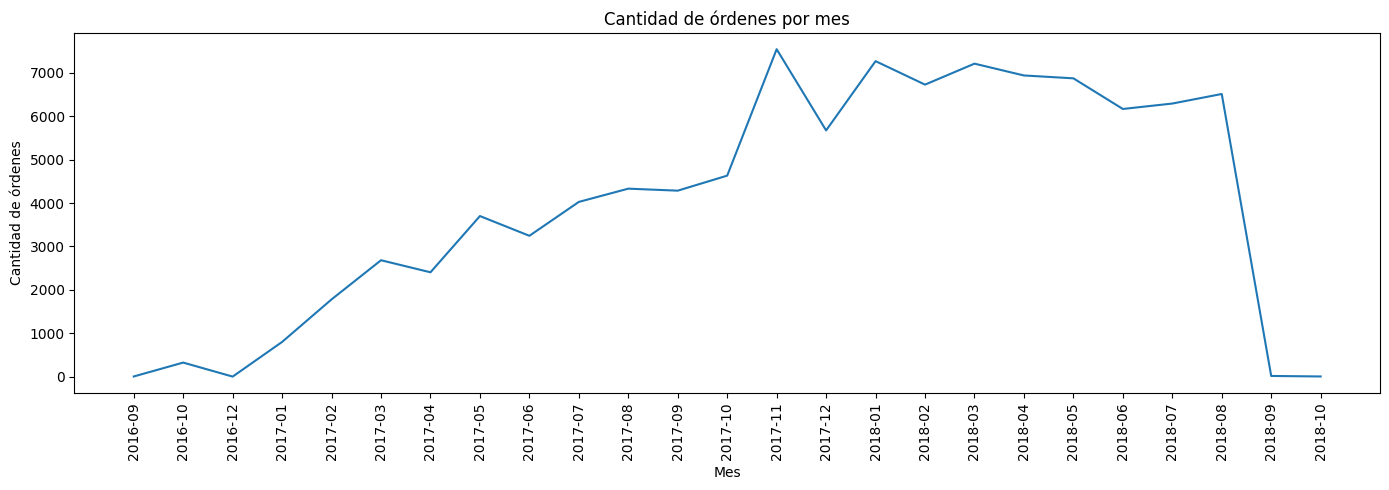

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(orders_by_month["order_month"], orders_by_month["cantidad_ordenes"])
plt.xticks(rotation=90)
plt.title("Cantidad de órdenes por mes")
plt.xlabel("Mes")
plt.ylabel("Cantidad de órdenes")
plt.tight_layout()
plt.show()



---


**Distribución geográfica inicial**

Clientes por estado:

In [ ]:
customers_by_state = (
    customers
    .groupby("customer_state")
    .size()
    .reset_index(name="cantidad_clientes")
    .sort_values(by="cantidad_clientes", ascending=False)
)

customers_by_state

,customer_state,cantidad_clientes
25,SP,41746
18,RJ,12852
10,MG,11635
22,RS,5466
17,PR,5045
23,SC,3637
4,BA,3380
6,DF,2140
7,ES,2033
8,GO,2020


---
Al graficar

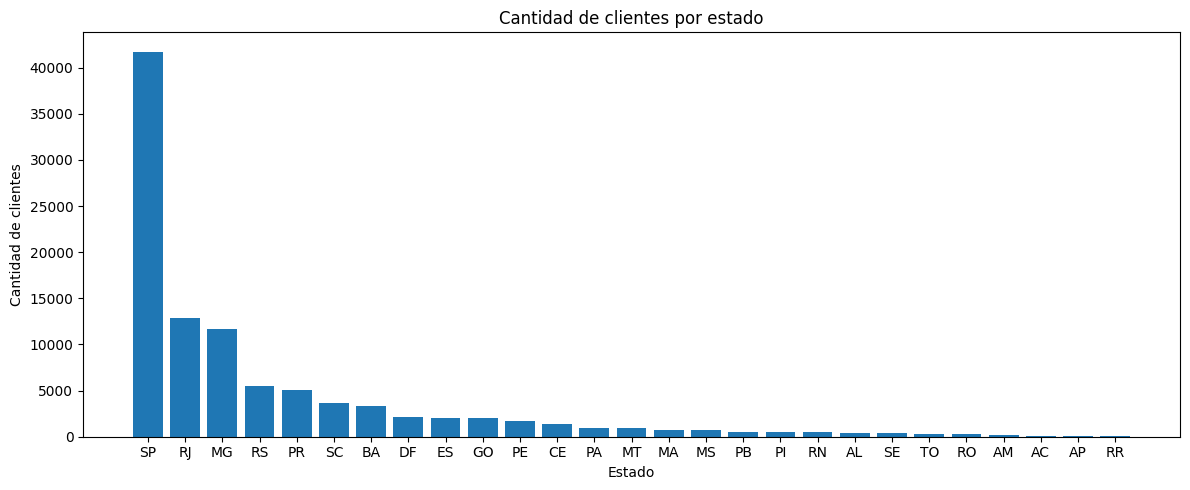

In [ ]:
plt.figure(figsize=(12, 5))
plt.bar(customers_by_state["customer_state"], customers_by_state["cantidad_clientes"])
plt.title("Cantidad de clientes por estado")
plt.xlabel("Estado")
plt.ylabel("Cantidad de clientes")
plt.tight_layout()
plt.show()



---


Vendedores por estado:

In [ ]:
sellers_by_state = (
    sellers
    .groupby("seller_state")
    .size()
    .reset_index(name="cantidad_vendedores")
    .sort_values(by="cantidad_vendedores", ascending=False)
)

sellers_by_state

,seller_state,cantidad_vendedores
22,SP,1849
15,PR,349
8,MG,244
20,SC,190
16,RJ,171
19,RS,129
6,GO,40
4,DF,30
5,ES,23
2,BA,19




---


Al graficar:

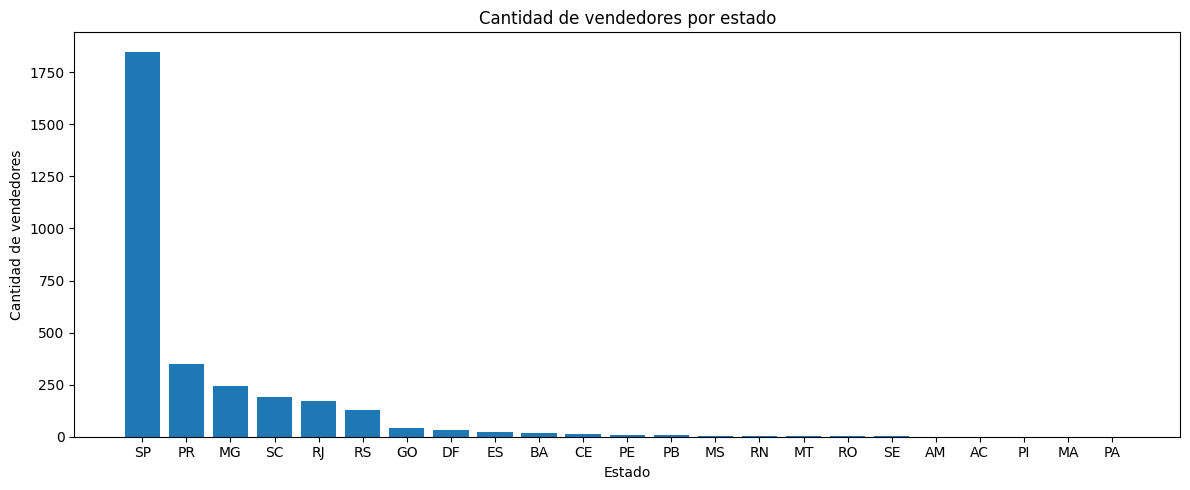

In [ ]:
plt.figure(figsize=(12, 5))
plt.bar(sellers_by_state["seller_state"], sellers_by_state["cantidad_vendedores"])
plt.title("Cantidad de vendedores por estado")
plt.xlabel("Estado")
plt.ylabel("Cantidad de vendedores")
plt.tight_layout()
plt.show()



---


**Conclusiones Iniciales**

In [ ]:
print("RESUMEN INICIAL, OLIST DATASET")
print("=" * 80)

print(f"Total de tablas cargadas: {len(dfs)}")
print(f"Total de órdenes: {orders.shape[0]}")
print(f"Total de clientes: {customers.shape[0]}")
print(f"Total de productos: {products.shape[0]}")
print(f"Total de vendedores: {sellers.shape[0]}")
print(f"Total de ítems de orden: {order_items.shape[0]}")
print(f"Total de pagos: {order_payments.shape[0]}")
print(f"Total de reviews: {order_reviews.shape[0]}")

print("\nRango temporal de órdenes:")
print("Fecha mínima:", orders["order_purchase_timestamp"].min())
print("Fecha máxima:", orders["order_purchase_timestamp"].max())

print("\nTop 5 estados con más clientes:")
display(customers_by_state.head())

print("\nTop 5 estados con más vendedores:")
display(sellers_by_state.head())

RESUMEN INICIAL, OLIST DATASET
Total de tablas cargadas: 9
Total de órdenes: 99441
Total de clientes: 99441
Total de productos: 32951
Total de vendedores: 3095
Total de ítems de orden: 112650
Total de pagos: 103886
Total de reviews: 99224

Rango temporal de órdenes:
Fecha mínima: 2016-09-04 21:15:19
Fecha máxima: 2018-10-17 17:30:18

Top 5 estados con más clientes:


,customer_state,cantidad_clientes
25,SP,41746
18,RJ,12852
10,MG,11635
22,RS,5466
17,PR,5045



Top 5 estados con más vendedores:


,seller_state,cantidad_vendedores
22,SP,1849
15,PR,349
8,MG,244
20,SC,190
16,RJ,171


### Hallazgos  EDA

El análisis exploratorio inicial permitió revisar la estructura de las 9 tablas del dataset Brazilian E-commerce / Olist.
Se identificó el volumen de registros por tabla, los tipos de datos, la presencia de valores nulos y posibles duplicados.

También se realizó una primera validación de relaciones entre tablas mediante columnas como `order_id`, `customer_id`, `product_id` y `seller_id`.
Estas relaciones serán la base para el posterior modelado conceptual, lógico y físico de la solución.

Además, se exploró la distribución temporal de las órdenes y la distribución geográfica de clientes y vendedores, información relevante para definir decisiones arquitectónicas relacionadas con particionamiento, análisis geográfico y separación entre cargas transaccionales y analíticas.

## 7. Documentación de hallazgos del EDA

En esta sección se consolidan  hallazgos del análisis del dataset Brazilian E-commerce / Olist.

Se resume:
 estructura, volumen, calidad de datos, relaciones principales, comportamiento

*   Estructura
*   Volumen
*   Calidad de datos
*   Relaciones principales
*   Comportamiento Temporal
*   Distribucion Geográfica

---
Se crea una carpeta de salidas para guardar resultados

In [ ]:
docs_path = project_path / "docs"
outputs_path = project_path / "outputs" / "eda"

docs_path.mkdir(parents=True, exist_ok=True)
outputs_path.mkdir(parents=True, exist_ok=True)

print("Carpeta de documentación:", docs_path)
print("Carpeta de resultados EDA:", outputs_path)

Carpeta de documentación: /content/drive/MyDrive/Maestria Arquitectura de software/Bases de Datos/Ecommify/data/raw/docs
Carpeta de resultados EDA: /content/drive/MyDrive/Maestria Arquitectura de software/Bases de Datos/Ecommify/data/raw/outputs/eda


---
**Exportar tablas resumen del EDA**

Se ejecuta el python con el fin de guardar los resultados

In [ ]:
eda_summary_df.to_csv(outputs_path / "01_resumen_tablas.csv", index=False)

if "null_report_df" in globals() and not null_report_df.empty:
    null_report_df.to_csv(outputs_path / "02_reporte_nulos_por_columna.csv", index=False)

if "nulls_by_table" in globals():
    pd.DataFrame(nulls_by_table).to_csv(outputs_path / "03_reporte_nulos_por_tabla.csv", index=False)

if "relationship_checks_df" in globals():
    relationship_checks_df.to_csv(outputs_path / "04_validacion_relaciones.csv", index=False)

if "orders_by_month" in globals():
    orders_by_month.to_csv(outputs_path / "05_ordenes_por_mes.csv", index=False)

if "customers_by_state" in globals():
    customers_by_state.to_csv(outputs_path / "06_clientes_por_estado.csv", index=False)

if "sellers_by_state" in globals():
    sellers_by_state.to_csv(outputs_path / "07_vendedores_por_estado.csv", index=False)

print("Archivos de resultados exportados correctamente.")

Archivos de resultados exportados correctamente.


---
Para generar un reporte automático en Markdown

El script va a generar un archivo: "reporte_eda_actividad1.md"

In [ ]:
def df_to_md(df, max_rows=12):
    df2 = df.head(max_rows).copy()
    cols = [str(c) for c in df2.columns]

    lines = []
    lines.append("| " + " | ".join(cols) + " |")
    lines.append("| " + " | ".join(["---"] * len(cols)) + " |")

    for _, row in df2.iterrows():
        values = [str(row[c]) for c in df2.columns]
        lines.append("| " + " | ".join(values) + " |")

    return "\n".join(lines)


total_tablas = len(dfs)
total_registros = sum(df.shape[0] for df in dfs.values())

fecha_min = orders["order_purchase_timestamp"].min()
fecha_max = orders["order_purchase_timestamp"].max()

top_estado_clientes = customers_by_state.iloc[0]["customer_state"]
top_cantidad_clientes = customers_by_state.iloc[0]["cantidad_clientes"]

top_estado_vendedores = sellers_by_state.iloc[0]["seller_state"]
top_cantidad_vendedores = sellers_by_state.iloc[0]["cantidad_vendedores"]

reporte = f"""
# Reporte inicial de EDA - Proyecto Integrador Ecommify

## 1. Contexto

El reporte documenta hallazgos iniciales del análisis exploratorio del dataset Brazilian E-commerce / Olist, utilizado como base para el diseño de una arquitectura híbrida PostgreSQL-MongoDB para Ecommify.

El dataset contiene información relacionada con clientes, vendedores, productos, pedidos, pagos, reseñas, geolocalización, ítems de pedido y traducción de categorías.

## 2. Resumen general del dataset

- Total de tablas cargadas: {total_tablas}
- Total de registros considerando todas las tablas: {total_registros}
- Total de órdenes: {orders.shape[0]}
- Total de clientes: {customers.shape[0]}
- Total de productos: {products.shape[0]}
- Total de vendedores: {sellers.shape[0]}
- Total de ítems de pedido: {order_items.shape[0]}
- Total de pagos: {order_payments.shape[0]}
- Total de reseñas: {order_reviews.shape[0]}

## 3. Estructura y volumen por tabla

{df_to_md(eda_summary_df, max_rows=20)}

## 4. Calidad de datos

Durante la revisión de calidad se analizaron valores nulos y registros duplicados.
Las columnas con valores nulos deberán revisarse con mayor detalle antes de definir restricciones `NOT NULL`, reglas de limpieza o estrategias de carga hacia PostgreSQL y MongoDB.

### Resumen de nulos por tabla

{df_to_md(pd.DataFrame(nulls_by_table).sort_values(by="total_nulos", ascending=False), max_rows=20)}

## 5. Relaciones principales identificadas

Se validaron relaciones iniciales entre tablas usando campos como `order_id`, `customer_id`, `product_id` y `seller_id`.
Estas relaciones serán la base para el posterior modelado conceptual y lógico.

{df_to_md(relationship_checks_df, max_rows=20)}

## 6. Distribución temporal

El rango temporal de las órdenes va desde:

- Fecha mínima de compra: {fecha_min}
- Fecha máxima de compra: {fecha_max}

Esta información será útil para decisiones posteriores de particionamiento, análisis histórico y diseño de consultas por rango de fechas.

## 7. Distribución geográfica

El estado con mayor cantidad de clientes es `{top_estado_clientes}`, con {top_cantidad_clientes} clientes registrados.

El estado con mayor cantidad de vendedores es `{top_estado_vendedores}`, con {top_cantidad_vendedores} vendedores registrados.

Esta distribución geográfica puede apoyar decisiones analíticas relacionadas con cobertura regional, concentración de mercado y posibles consultas geoespaciales.

## 8. Implicaciones iniciales para la arquitectura híbrida

A partir del EDA inicial se identifican dos grandes tipos de datos:

1. Datos transaccionales:
   - Órdenes
   - Pagos
   - Ítems de pedido
   - Clientes
   - Vendedores

   Estos datos presentan relaciones claras entre tablas y requieren integridad referencial, por lo que son candidatos naturales para PostgreSQL.

2. Datos analíticos o semi-estructurados:
   - Catálogo de productos
   - Reseñas
   - Información enriquecida de productos
   - Posibles agregados de comportamiento de usuarios

   Estos datos pueden beneficiarse de mayor flexibilidad de esquema y de modelos orientados a documentos, por lo que son candidatos para MongoDB.

## 9. Conclusión preliminar

El dataset Olist ofrece una base adecuada para simular el caso Ecommify, ya que contiene datos transaccionales, información de catálogo, pagos, reseñas y ubicación geográfica.

El análisis inicial confirma que existen relaciones estructuradas entre varias tablas, lo cual respalda el uso de PostgreSQL para el núcleo transaccional.
También se identifican entidades con potencial analítico, como productos, reseñas y comportamiento de pedidos, que pueden ser evaluadas para un modelo documental en MongoDB.

Los hallazgos de esta etapa servirán como insumo para la definición del enfoque arquitectónico, la formulación de preguntas de investigación y el diseño conceptual, lógico y físico del proyecto.
"""

report_path = docs_path / "reporte_eda_actividad1.md"

with open(report_path, "w", encoding="utf-8") as f:
    f.write(reporte)

print(f"Reporte generado en: {report_path}")

Reporte generado en: /content/drive/MyDrive/Maestria Arquitectura de software/Bases de Datos/Ecommify/data/raw/docs/reporte_eda_actividad1.md


---
**Mostar el reporte**

In [ ]:
from IPython.display import Markdown, display

display(Markdown(reporte))


# Reporte inicial de EDA - Proyecto Integrador Ecommify

## 1. Contexto

El reporte documenta hallazgos iniciales del análisis exploratorio del dataset Brazilian E-commerce / Olist, utilizado como base para el diseño de una arquitectura híbrida PostgreSQL-MongoDB para Ecommify.

El dataset contiene información relacionada con clientes, vendedores, productos, pedidos, pagos, reseñas, geolocalización, ítems de pedido y traducción de categorías.

## 2. Resumen general del dataset

- Total de tablas cargadas: 9
- Total de registros considerando todas las tablas: 1550922
- Total de órdenes: 99441
- Total de clientes: 99441
- Total de productos: 32951
- Total de vendedores: 3095
- Total de ítems de pedido: 112650
- Total de pagos: 103886
- Total de reseñas: 99224

## 3. Estructura y volumen por tabla

| tabla | filas | columnas | duplicados | valores_nulos_totales |
| --- | --- | --- | --- | --- |
| geolocation | 1000163 | 5 | 261831 | 0 |
| order_items | 112650 | 7 | 0 | 0 |
| order_payments | 103886 | 5 | 0 | 0 |
| customers | 99441 | 5 | 0 | 0 |
| orders | 99441 | 8 | 0 | 4908 |
| order_reviews | 99224 | 7 | 0 | 145903 |
| products | 32951 | 9 | 0 | 2448 |
| sellers | 3095 | 4 | 0 | 0 |
| category_translation | 71 | 2 | 0 | 0 |

## 4. Calidad de datos

Durante la revisión de calidad se analizaron valores nulos y registros duplicados. 
Las columnas con valores nulos deberán revisarse con mayor detalle antes de definir restricciones `NOT NULL`, reglas de limpieza o estrategias de carga hacia PostgreSQL y MongoDB.

### Resumen de nulos por tabla

| tabla | total_nulos | columnas_con_nulos |
| --- | --- | --- |
| order_reviews | 145903 | 2 |
| orders | 4908 | 3 |
| products | 2448 | 8 |
| customers | 0 | 0 |
| geolocation | 0 | 0 |
| order_payments | 0 | 0 |
| order_items | 0 | 0 |
| sellers | 0 | 0 |
| category_translation | 0 | 0 |

## 5. Relaciones principales identificadas

Se validaron relaciones iniciales entre tablas usando campos como `order_id`, `customer_id`, `product_id` y `seller_id`. 
Estas relaciones serán la base para el posterior modelado conceptual y lógico.

| relacion | porcentaje_coincidencia |
| --- | --- |
| orders.customer_id -> customers.customer_id | 100.0 |
| order_items.order_id -> orders.order_id | 100.0 |
| order_payments.order_id -> orders.order_id | 100.0 |
| order_reviews.order_id -> orders.order_id | 100.0 |
| order_items.product_id -> products.product_id | 100.0 |
| order_items.seller_id -> sellers.seller_id | 100.0 |
| products.product_category_name -> category_translation.product_category_name | 99.96 |

## 6. Distribución temporal

El rango temporal de las órdenes va desde:

- Fecha mínima de compra: 2016-09-04 21:15:19
- Fecha máxima de compra: 2018-10-17 17:30:18

Esta información será útil para decisiones posteriores de particionamiento, análisis histórico y diseño de consultas por rango de fechas.

## 7. Distribución geográfica

El estado con mayor cantidad de clientes es `SP`, con 41746 clientes registrados.

El estado con mayor cantidad de vendedores es `SP`, con 1849 vendedores registrados.

Esta distribución geográfica puede apoyar decisiones analíticas relacionadas con cobertura regional, concentración de mercado y posibles consultas geoespaciales.

## 8. Implicaciones iniciales para la arquitectura híbrida

A partir del EDA inicial se identifican dos grandes tipos de datos:

1. Datos transaccionales:
   - Órdenes
   - Pagos
   - Ítems de pedido
   - Clientes
   - Vendedores

   Estos datos presentan relaciones claras entre tablas y requieren integridad referencial, por lo que son candidatos naturales para PostgreSQL.

2. Datos analíticos o semi-estructurados:
   - Catálogo de productos
   - Reseñas
   - Información enriquecida de productos
   - Posibles agregados de comportamiento de usuarios

   Estos datos pueden beneficiarse de mayor flexibilidad de esquema y de modelos orientados a documentos, por lo que son candidatos para MongoDB.

## 9. Conclusión preliminar

El dataset Olist ofrece una base adecuada para simular el caso Ecommify, ya que contiene datos transaccionales, información de catálogo, pagos, reseñas y ubicación geográfica.

El análisis inicial confirma que existen relaciones estructuradas entre varias tablas, lo cual respalda el uso de PostgreSQL para el núcleo transaccional. 
También se identifican entidades con potencial analítico, como productos, reseñas y comportamiento de pedidos, que pueden ser evaluadas para un modelo documental en MongoDB.

Los hallazgos de esta etapa servirán como insumo para la definición del enfoque arquitectónico, la formulación de preguntas de investigación y el diseño conceptual, lógico y físico del proyecto.
